In [1]:
import functools
import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from scipy.stats import wilcoxon
from tqdm.auto import tqdm

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from constants import (
    CAPTIONS_PATH,
    CVA_EM_PATHS,
    ERA_EM_PATHS,
    FIGURES_PATH,
    LATENT_DIMS,
    N_BURNIN,
)
from obs_reconstruction import (
    NOTEBOOK_GITHUB_URL,
    make_obs_reconstruction_figure,
    run_trial,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from system_estimate import SystemEstimate

In [2]:
# ── experiment constants ───────────────────────────────────────────────────────
N_TEST_SEEDS    = 1000    # trials; seeds 10…59 (avoids training seeds 0–2)
FIRST_TEST_SEED = 10
T_TEST   = 2000         # timesteps per trial
T_BURNIN = N_BURNIN     # burn-in before recording
T_SKIP   = 100          # discard Kalman transient before scoring R²

In [3]:
# ── load estimators ───────────────────────────────────────────────────────────
# Grouped by n_x: each pair is (CVA+EM, ERA+EM) at the same latent dimension
ESTIMATE_GROUPS: list[list[SystemEstimate]] = [
    [SystemEstimate.load(cva_path), SystemEstimate.load(era_path)]
    for cva_path, era_path in zip(CVA_EM_PATHS, ERA_EM_PATHS)
]
ESTIMATES: list[SystemEstimate] = [est for group in ESTIMATE_GROUPS for est in group]
TEST_SEEDS = list(range(FIRST_TEST_SEED, FIRST_TEST_SEED + N_TEST_SEEDS))

for est in ESTIMATES:
    sr = float(np.max(np.abs(np.linalg.eigvals(est.A))))
    print(f"{est.label:25s}  spectral radius: {sr:.4f}")
print(f"Test seeds: {TEST_SEEDS[0]}–{TEST_SEEDS[-1]}  (N = {N_TEST_SEEDS})")

CVA+EM $n_x=2$             spectral radius: 0.9422
ERA+EM $n_x=2$             spectral radius: 0.9424
CVA+EM $n_x=4$             spectral radius: 0.9410
ERA+EM $n_x=4$             spectral radius: 0.9719
CVA+EM $n_x=6$             spectral radius: 0.9408
ERA+EM $n_x=6$             spectral radius: 0.9709
Test seeds: 10–1009  (N = 1000)


In [4]:
# ── run trials in parallel ────────────────────────────────────────────────────
_run = functools.partial(
    run_trial,
    n_steps=T_TEST,
    n_burnin=T_BURNIN,
    estimates=ESTIMATES,
    t_skip=T_SKIP,
)

raw_results: list = [None] * N_TEST_SEEDS
with tqdm(total=N_TEST_SEEDS, desc="Test trials") as pbar:
    for i, res in enumerate(
        Parallel(n_jobs=-1, return_as="generator_unordered")(
            delayed(_run)(seed) for seed in TEST_SEEDS
        )
    ):
        raw_results[i] = res
        pbar.update(1)
        pbar.set_postfix(completed=i + 1)

# ── aggregate results ─────────────────────────────────────────────────────────
r2f_all = {est.name: np.array([r[est.name][1] for r in raw_results]) for est in ESTIMATES}

data = dict(estimate_groups=ESTIMATE_GROUPS, r2f=r2f_all, latent_dims=LATENT_DIMS)

# ── critical metrics ──────────────────────────────────────────────────────────
for est in ESTIMATES:
    frob_med = float(np.median(r2f_all[est.name]))
    print(f"{est.label:25s}  median R²_F = {frob_med:.4f}")

print()

# Pairwise Wilcoxon signed-rank tests: CVA+EM vs ERA+EM within each n_x
for cva_est, era_est in ESTIMATE_GROUPS:
    w, p = wilcoxon(r2f_all[cva_est.name], r2f_all[era_est.name], alternative="two-sided")
    n_x = cva_est.A.shape[0]
    print(f"Wilcoxon n_x={n_x}: CVA+EM vs ERA+EM  W = {w:.1f},  p = {p:.4e}")

Test trials:   0%|          | 0/1000 [00:00<?, ?it/s]

CVA+EM $n_x=2$             median R²_F = 0.3994
ERA+EM $n_x=2$             median R²_F = 0.3994
CVA+EM $n_x=4$             median R²_F = 0.3991
ERA+EM $n_x=4$             median R²_F = 0.4001
CVA+EM $n_x=6$             median R²_F = 0.3989
ERA+EM $n_x=6$             median R²_F = 0.3997

Wilcoxon n_x=2: CVA+EM vs ERA+EM  W = 166339.0,  p = 4.1114e-20
Wilcoxon n_x=4: CVA+EM vs ERA+EM  W = 8823.0,  p = 6.6758e-154
Wilcoxon n_x=6: CVA+EM vs ERA+EM  W = 9829.0,  p = 1.2233e-152


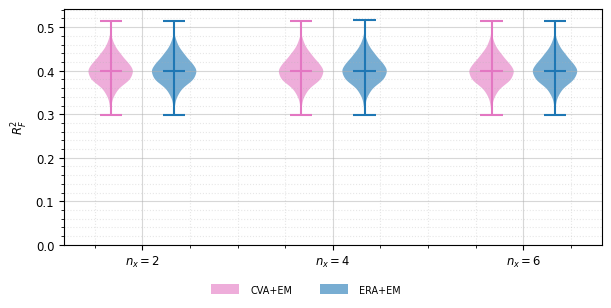

In [5]:
# ── display ────────────────────────────────────────────────────────────────────
configure_screen()
fig = make_obs_reconstruction_figure(data, figsize=(6, 3))
apply_figure_style(fig)
plt.show()

In [6]:
# ── pgf export ─────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 0.5
FIG_HEIGHT_FRAC = 0.15

configure_pgf()
fig = make_obs_reconstruction_figure(
    data, figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC)
)
save_pgf(fig, FIGURES_PATH / "obs_reconstruction.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/obs_reconstruction.pgf


In [7]:
# ── caption ────────────────────────────────────────────────────────────────────
method_strs = []
for cva_est, era_est in ESTIMATE_GROUPS:
    n_x = cva_est.A.shape[0]
    cva_med = float(np.median(r2f_all[cva_est.name]))
    era_med = float(np.median(r2f_all[era_est.name]))
    method_strs.append(
        rf"$n_x = {n_x}$: CVA+EM $= {cva_med:.3f}$, ERA+EM $= {era_med:.3f}$"
    )

caption = (
    rf"Frobenius $R^2_F$ of one-step-ahead Kalman predictions for CVA+EM and ERA+EM "
    rf"at $n_x \in \{{{', '.join(str(d) for d in LATENT_DIMS)}\}}$, "
    rf"across $N = {N_TEST_SEEDS}$ held-out trials of $T = {T_TEST}$ steps "
    rf"(first {T_SKIP} steps excluded as Kalman transient). "
    + "Median $R^2_F$: "
    + "; ".join(method_strs)
    + "."
)

save_caption(CAPTIONS_PATH / "obs_reconstruction.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/obs_reconstruction.tex
Frobenius $R^2_F$ of one-step-ahead Kalman predictions for CVA+EM and ERA+EM at $n_x \in \{2, 4, 6\}$, across $N = 1000$ held-out trials of $T = 2000$ steps (first 100 steps excluded as Kalman transient). Median $R^2_F$: $n_x = 2$: CVA+EM $= 0.399$, ERA+EM $= 0.399$; $n_x = 4$: CVA+EM $= 0.399$, ERA+EM $= 0.400$; $n_x = 6$: CVA+EM $= 0.399$, ERA+EM $= 0.400$.
